# 컨버전스 그래프

In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.preprocessing import MinMaxScaler

from datasets import CubeObstacle, CylinderObstacle

# Load the data
train_data = pd.read_csv('data/conversion_graph/train_loss.csv')
val_data = pd.read_csv('data/conversion_graph/val_loss.csv')

In [2]:
train_data.head()

,Step,lr_test: 1e-05 - train_loss,lr_test: 1e-05 - train_loss__MIN,lr_test: 1e-05 - train_loss__MAX,lr_test: 5e-05 - train_loss,lr_test: 5e-05 - train_loss__MIN,lr_test: 5e-05 - train_loss__MAX,lr_test: 0.0001 - train_loss,lr_test: 0.0001 - train_loss__MIN,lr_test: 0.0001 - train_loss__MAX,lr_test: 0.0005 - train_loss,lr_test: 0.0005 - train_loss__MIN,lr_test: 0.0005 - train_loss__MAX,lr_test: 0.001 - train_loss,lr_test: 0.001 - train_loss__MIN,lr_test: 0.001 - train_loss__MAX
0,0,-11.623576,-11.623576,-11.623576,-11.704751,-11.704751,-11.704751,-11.742593,-11.742593,-11.742593,-11.739704,-11.739704,-11.739704,-11.721711,-11.721711,-11.721711
1,1,-11.648657,-11.648657,-11.648657,-11.842835,-11.842835,-11.842835,-11.880994,-11.880994,-11.880994,-11.811300,-11.811300,-11.811300,-11.869543,-11.869543,-11.869543
2,2,-11.687406,-11.687406,-11.687406,-11.891510,-11.891510,-11.891510,-11.927698,-11.927698,-11.927698,-11.863114,-11.863114,-11.863114,-11.876957,-11.876957,-11.876957
3,3,-11.720389,-11.720389,-11.720389,-11.913767,-11.913767,-11.913767,-11.941534,-11.941534,-11.941534,-11.916936,-11.916936,-11.916936,-11.816933,-11.816933,-11.816933
4,4,-11.755287,-11.755287,-11.755287,-11.922959,-11.922959,-11.922959,-11.942869,-11.942869,-11.942869,-11.918828,-11.918828,-11.918828,-11.841391,-11.841391,-11.841391


In [3]:
val_data.head()

,Step,lr_test: 1e-05 - val_loss,lr_test: 1e-05 - val_loss__MIN,lr_test: 1e-05 - val_loss__MAX,lr_test: 5e-05 - val_loss,lr_test: 5e-05 - val_loss__MIN,lr_test: 5e-05 - val_loss__MAX,lr_test: 0.0001 - val_loss,lr_test: 0.0001 - val_loss__MIN,lr_test: 0.0001 - val_loss__MAX,lr_test: 0.0005 - val_loss,lr_test: 0.0005 - val_loss__MIN,lr_test: 0.0005 - val_loss__MAX,lr_test: 0.001 - val_loss,lr_test: 0.001 - val_loss__MIN,lr_test: 0.001 - val_loss__MAX
0,0,-11.609613,-11.609613,-11.609613,-11.786407,-11.786407,-11.786407,-11.847040,-11.847040,-11.847040,-11.881181,-11.881181,-11.881181,-11.797419,-11.797419,-11.797419
1,1,-11.640531,-11.640531,-11.640531,-11.886848,-11.886848,-11.886848,-11.933800,-11.933800,-11.933800,-11.860139,-11.860139,-11.860139,-11.763832,-11.763832,-11.763832
2,2,-11.677354,-11.677354,-11.677354,-11.915521,-11.915521,-11.915521,-11.945092,-11.945092,-11.945092,-11.907888,-11.907888,-11.907888,-11.911105,-11.911105,-11.911105
3,3,-11.716187,-11.716187,-11.716187,-11.926936,-11.926936,-11.926936,-11.949705,-11.949705,-11.949705,-11.938829,-11.938829,-11.938829,-11.844799,-11.844799,-11.844799
4,4,-11.755092,-11.755092,-11.755092,-11.949523,-11.949523,-11.949523,-11.939426,-11.939426,-11.939426,-11.887528,-11.887528,-11.887528,-11.896841,-11.896841,-11.896841


In [4]:
# data preprocessing

train_data = train_data[['lr_test: 0.001 - train_loss', 'lr_test: 0.0005 - train_loss', 'lr_test: 0.0001 - train_loss', 'lr_test: 5e-05 - train_loss', 'lr_test: 1e-05 - train_loss']]

train_data.columns = ['1e-3', '5e-4', '1e-4', '5e-5', '1e-5']

val_data = val_data[['lr_test: 0.001 - val_loss', 'lr_test: 0.0005 - val_loss', 'lr_test: 0.0001 - val_loss', 'lr_test: 5e-05 - val_loss', 'lr_test: 1e-05 - val_loss']]
val_data.columns = ['1e-3', '5e-4', '1e-4', '5e-5', '1e-5']

In [5]:
train_data.head()

,1e-3,5e-4,1e-4,5e-5,1e-5
0,-11.721711,-11.739704,-11.742593,-11.704751,-11.623576
1,-11.869543,-11.811300,-11.880994,-11.842835,-11.648657
2,-11.876957,-11.863114,-11.927698,-11.891510,-11.687406
3,-11.816933,-11.916936,-11.941534,-11.913767,-11.720389
4,-11.841391,-11.918828,-11.942869,-11.922959,-11.755287


In [6]:
val_data.head()

,1e-3,5e-4,1e-4,5e-5,1e-5
0,-11.797419,-11.881181,-11.847040,-11.786407,-11.609613
1,-11.763832,-11.860139,-11.933800,-11.886848,-11.640531
2,-11.911105,-11.907888,-11.945092,-11.915521,-11.677354
3,-11.844799,-11.938829,-11.949705,-11.926936,-11.716187
4,-11.896841,-11.887528,-11.939426,-11.949523,-11.755092


In [7]:
# import numpy as np
# import matplotlib.pyplot as plt
# import matplotlib.scale as mscale
# import matplotlib.transforms as mtransforms
# from matplotlib.ticker import MultipleLocator, FormatStrFormatter
#
# # === 커스텀 변환 및 스케일 클래스 정의 ===
# class BrokenAxisTransform(mtransforms.Transform):
#     input_dims = output_dims = 1
#     is_separable = True
#
#     def __init__(self, break_lower, break_upper, factor=0.5):
#         super().__init__()
#         self.break_lower = break_lower
#         self.break_upper = break_upper
#         self.factor = factor
#
#     def transform_non_affine(self, a):
#         a = np.asarray(a)
#         result = a.copy()
#         # break 구간 내에서는 압축 적용
#         mask = (a >= self.break_lower) & (a <= self.break_upper)
#         result[mask] = self.break_lower + (a[mask] - self.break_lower) * self.factor
#         # break 구간 위의 값은 shift 처리
#         mask2 = a > self.break_upper
#         result[mask2] = a[mask2] - (1 - self.factor) * (self.break_upper - self.break_lower)
#         return result
#
#     def inverted(self):
#         return InvertedBrokenAxisTransform(self.break_lower, self.break_upper, self.factor)
#
# class InvertedBrokenAxisTransform(mtransforms.Transform):
#     input_dims = output_dims = 1
#     is_separable = True
#
#     def __init__(self, break_lower, break_upper, factor):
#         super().__init__()
#         self.break_lower = break_lower
#         self.break_upper = break_upper
#         self.factor = factor
#
#     def transform_non_affine(self, a):
#         a = np.asarray(a)
#         result = a.copy()
#         # 압축된 구간의 역변환
#         mask = (a >= self.break_lower) & (a < self.break_lower + (self.break_upper - self.break_lower)*self.factor)
#         result[mask] = self.break_lower + (a[mask] - self.break_lower) / self.factor
#         # shift된 값들의 복원
#         mask2 = a >= self.break_lower + (self.break_upper - self.break_lower)*self.factor
#         result[mask2] = a[mask2] + (1 - self.factor) * (self.break_upper - self.break_lower)
#         return result
#
#     def inverted(self):
#         return BrokenAxisTransform(self.break_lower, self.break_upper, self.factor)
#
# class BrokenAxisScale(mscale.ScaleBase):
#     name = 'broken'
#
#     def __init__(self, axis, **kwargs):
#         super().__init__(axis)
#         self.break_lower = kwargs.get('break_lower', -12)
#         self.break_upper = kwargs.get('break_upper', -11.6)
#         self.factor = kwargs.get('factor', 0.15)
#
#     def get_transform(self):
#         return BrokenAxisTransform(self.break_lower, self.break_upper, self.factor)
#
#     def set_default_locators_and_formatters(self, axis):
#         axis.set_major_locator(MultipleLocator(0.05))
#         axis.set_major_formatter(FormatStrFormatter('%.2f'))
#
#     def limit_range_for_scale(self, vmin, vmax, minpos):
#         return vmin, vmax
#
# mscale.register_scale(BrokenAxisScale)

In [8]:

# # === 서브플롯 생성 (위: Training, 아래: Validation) ===
# fig, (ax_train, ax_val) = plt.subplots(2, 1, figsize=(8, 8), sharex=True)
#
# # --- Training Loss 플롯 ---
# ax_train.set_yscale('broken', break_lower=-12, break_upper=-11.6, factor=0.15)
# for col in train_data.columns:
#     ax_train.plot(train_data.index, train_data[col], linewidth=1, label=col, alpha=0.7)
# ax_train.set_title('Training Loss')
# ax_train.set_ylabel('Loss')
# # major grid: 0.05 간격의 눈금이 적용됨
# ax_train.yaxis.set_major_locator(MultipleLocator(0.05))
# ax_train.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
# ax_train.grid(True)  # major grid
#
# # 서브(마이너) 그리드 추가
# ax_train.minorticks_on()
# ax_train.grid(which='minor', linestyle=':', linewidth=0.5, alpha=0.7)
# ax_train.legend()
#
# # --- Validation Loss 플롯 ---
# ax_val.set_yscale('broken', break_lower=-12, break_upper=-11.6, factor=0.15)
# for col in val_data.columns:
#     ax_val.plot(val_data.index, val_data[col], linewidth=1, label=col, alpha=0.7)
# ax_val.set_title('Validation Loss')
# ax_val.set_xlabel('Epochs')
# ax_val.set_ylabel('Loss')
# # major grid: 0.05 간격의 눈금이 적용됨
# ax_val.yaxis.set_major_locator(MultipleLocator(0.05))
# ax_val.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
# ax_val.grid(True)
#
# # 서브(마이너) 그리드 추가
# ax_val.minorticks_on()
# ax_val.grid(which='minor', linestyle=':', linewidth=0.5, alpha=0.7)
# ax_val.legend()
#
# plt.tight_layout()
#
# plt.savefig('./results/conversion_graph/loss_scaled.pdf', dpi=300)
# plt.savefig('./results/conversion_graph/loss_scaled.svg', dpi=300)
# plt.savefig('./results/conversion_graph/loss_scaled.eps', dpi=300)
# plt.savefig('./results/conversion_graph/loss_scaled.png', dpi=300)
#
# plt.show()

In [9]:
# from matplotlib.ticker import FuncFormatter
#
#
# # MinMax Scaling
# def min_max_scaling(x, feature_range=(0, 1), x_min=None, x_max=None):
#     """
#     주어진 1차원 배열 x를 feature_range에 맞게 스케일링합니다.
#
#     Parameters:
#       x : array-like, 입력 데이터
#       feature_range : tuple (new_min, new_max)
#
#     Returns:
#       scaled_x : array, 스케일링된 데이터
#     """
#     new_min, new_max = feature_range
#     if x_min is None:
#         x_min = np.min(x)
#     if x_max is None:
#         x_max = np.max(x)
#
#     # 분모가 0인 경우(모든 값이 같은 경우)를 처리
#     if x_max - x_min == 0:
#         return np.full_like(x, new_min, dtype=float)
#
#     scaled_x = new_min + (x - x_min) * (new_max - new_min) / (x_max - x_min)
#     return scaled_x
#
# a=-12.055
# b=-11.6
#
# def inv_formatter(y, pos):
#     # a == x_min
#     # b == x_max
#     return f"{a}+{(b-a)*y:.1e}"
#
# train_scaled = min_max_scaling(train_data, feature_range=(0.001, 10), x_min=a, x_max=b)
# val_scaled = min_max_scaling(val_data, feature_range=(0.1, 10), x_min=a, x_max=b)
#
# # === 서브플롯 생성 (위: Training, 아래: Validation) ===
# fig, (ax_train, ax_val) = plt.subplots(2, 1, figsize=(8, 8), sharex=True)
#
# # --- Training Loss 플롯 ---
# ax_train.set_yscale('log')
# for col in train_data.columns:
#     ax_train.plot(train_data.index, train_scaled[col], linewidth=1, label=col, alpha=0.7)
# ax_train.set_title('Training Loss')
# ax_train.set_ylabel('Loss')
# ax_train.yaxis.set_major_formatter(FuncFormatter(inv_formatter))
# ax_train.grid(True)  # major grid
#
# # 서브(마이너) 그리드 추가
# ax_train.minorticks_on()
# ax_train.grid(which='minor', linestyle=':', linewidth=0.5, alpha=0.7)
# ax_train.legend()
#
# # --- Validation Loss 플롯 ---
# ax_val.set_yscale('log')
# for col in val_data.columns:
#     ax_val.plot(val_data.index, val_scaled[col], linewidth=1, label=col, alpha=0.7)
# ax_val.set_title('Validation Loss')
# ax_val.set_xlabel('Epochs')
# ax_val.set_ylabel('Loss')
# ax_val.yaxis.set_major_formatter(FuncFormatter(inv_formatter))
# ax_val.grid(True)
#
# # 서브(마이너) 그리드 추가
# ax_val.minorticks_on()
# ax_val.grid(which='minor', linestyle=':', linewidth=0.5, alpha=0.7)
# ax_val.legend()
#
# plt.tight_layout()
#
# plt.savefig('./results/conversion_graph/loss_scaled.pdf', dpi=300)
# plt.savefig('./results/conversion_graph/loss_scaled.svg', dpi=300)
# plt.savefig('./results/conversion_graph/loss_scaled.eps', dpi=300)
# plt.savefig('./results/conversion_graph/loss_scaled.png', dpi=300)
#
# plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


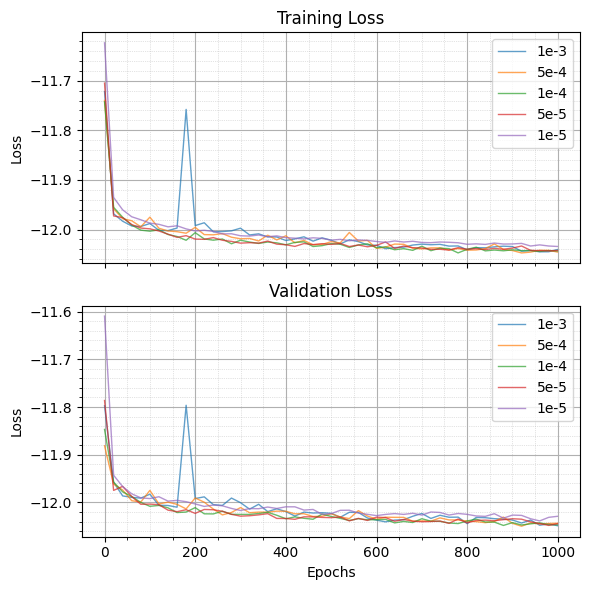

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.ticker import FuncFormatter

# train_data와 val_data가 Pandas DataFrame이라고 가정합니다.
# 인덱스가 25의 배수인 행만 선택한 후, 마지막 에폭(마지막 행)이 포함되어 있지 않으면 추가합니다.
def subset_with_last(df, mod=20):
    df_sub = df[df.index % mod == 0].copy()
    if df.index[-1] % mod != 0:
        df_sub = pd.concat([df_sub, df.iloc[[-1]]])
    return df_sub.sort_index()

train_data_sub = subset_with_last(train_data)
val_data_sub   = subset_with_last(val_data)


# === 서브플롯 생성 (위: Training, 아래: Validation) ===
fig, (ax_train, ax_val) = plt.subplots(2, 1, figsize=(6, 6), sharex=True)

# --- Training Loss 플롯 ---
for col in train_data_sub.columns:
    ax_train.plot(train_data_sub.index, train_data_sub[col], linewidth=1, label=col, alpha=0.7)
ax_train.set_title('Training Loss')
ax_train.set_ylabel('Loss')
ax_train.grid(True)
ax_train.minorticks_on()
ax_train.grid(which='minor', linestyle=':', linewidth=0.5, alpha=0.7)
ax_train.legend()

# --- Validation Loss 플롯 ---
for col in val_data_sub.columns:
    ax_val.plot(val_data_sub.index, val_data_sub[col], linewidth=1, label=col, alpha=0.7)
ax_val.set_title('Validation Loss')
ax_val.set_xlabel('Epochs')
ax_val.set_ylabel('Loss')
ax_val.grid(True)
ax_val.minorticks_on()
ax_val.grid(which='minor', linestyle=':', linewidth=0.5, alpha=0.7)
ax_val.legend()

plt.tight_layout()

plt.savefig('./results/conversion_graph/loss_scaled.pdf', dpi=300)
plt.savefig('./results/conversion_graph/loss_scaled.svg', dpi=300)
plt.savefig('./results/conversion_graph/loss_scaled.eps', dpi=300)
plt.savefig('./results/conversion_graph/loss_scaled.png', dpi=300)

plt.show()


# Ground Node 수에 따른 결과

In [11]:
# Load the data

se_df = pd.read_csv('data/gn_num_test/spectral_efficiency.csv')
time_df = pd.read_csv('data/gn_num_test/train_times.csv')

In [12]:
se_df.head()

,Step,gnd_test: 6 - test SE avg,gnd_test: 6 - test SE avg__MIN,gnd_test: 6 - test SE avg__MAX,gnd_test: 5 - test SE avg,gnd_test: 5 - test SE avg__MIN,gnd_test: 5 - test SE avg__MAX,gnd_test: 4 - test SE avg,gnd_test: 4 - test SE avg__MIN,gnd_test: 4 - test SE avg__MAX,gnd_test: 3 - test SE avg,gnd_test: 3 - test SE avg__MIN,gnd_test: 3 - test SE avg__MAX,gnd_test: 2 - test SE avg,gnd_test: 2 - test SE avg__MIN,gnd_test: 2 - test SE avg__MAX
0,1000,11.968668,11.968668,11.968668,12.000898,12.000898,12.000898,12.075259,12.075259,12.075259,12.162817,12.162817,12.162817,12.390271,12.390271,12.390271


In [13]:
time_df.head()

,Step,gnd_test: 6 - time,gnd_test: 6 - time__MIN,gnd_test: 6 - time__MAX,gnd_test: 5 - time,gnd_test: 5 - time__MIN,gnd_test: 5 - time__MAX,gnd_test: 4 - time,gnd_test: 4 - time__MIN,gnd_test: 4 - time__MAX,gnd_test: 3 - time,gnd_test: 3 - time__MIN,gnd_test: 3 - time__MAX,gnd_test: 2 - time,gnd_test: 2 - time__MIN,gnd_test: 2 - time__MAX
0,0,1.320237,1.320237,1.320237,1.031779,1.031779,1.031779,0.910367,0.910367,0.910367,0.805993,0.805993,0.805993,1.045682,1.045682,1.045682
1,1,0.972813,0.972813,0.972813,0.864102,0.864102,0.864102,0.716626,0.716626,0.716626,0.575668,0.575668,0.575668,0.433618,0.433618,0.433618
2,2,0.973122,0.973122,0.973122,0.869157,0.869157,0.869157,0.724938,0.724938,0.724938,0.582595,0.582595,0.582595,0.436076,0.436076,0.436076
3,3,0.972132,0.972132,0.972132,0.860154,0.860154,0.860154,0.717582,0.717582,0.717582,0.569443,0.569443,0.569443,0.435445,0.435445,0.435445
4,4,0.965587,0.965587,0.965587,0.868659,0.868659,0.868659,0.718867,0.718867,0.718867,0.573424,0.573424,0.573424,0.434258,0.434258,0.434258


In [14]:
# data preprocessing

se_df = se_df[["gnd_test: 2 - test SE avg", "gnd_test: 3 - test SE avg", "gnd_test: 4 - test SE avg", "gnd_test: 5 - test SE avg", "gnd_test: 6 - test SE avg"]]
se_df.columns = ['2', '3', '4', '5', '6']

time_df = time_df[["gnd_test: 2 - time", "gnd_test: 3 - time", "gnd_test: 4 - time", "gnd_test: 5 - time", "gnd_test: 6 - time"]]
time_df.columns = ['2', '3', '4', '5', '6']

In [15]:
se_df.head()

,2,3,4,5,6
0,12.390271,12.162817,12.075259,12.000898,11.968668


In [16]:
time_df.head()

,2,3,4,5,6
0,1.045682,0.805993,0.910367,1.031779,1.320237
1,0.433618,0.575668,0.716626,0.864102,0.972813
2,0.436076,0.582595,0.724938,0.869157,0.973122
3,0.435445,0.569443,0.717582,0.860154,0.972132
4,0.434258,0.573424,0.718867,0.868659,0.965587


In [17]:
time_arr = np.array(time_df, dtype=np.float32)
time_avg = np.mean(time_arr, axis=0)
time_avg

array([0.4505869 , 0.5893395 , 0.72965556, 0.85815614, 0.98488915],
      dtype=float32)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


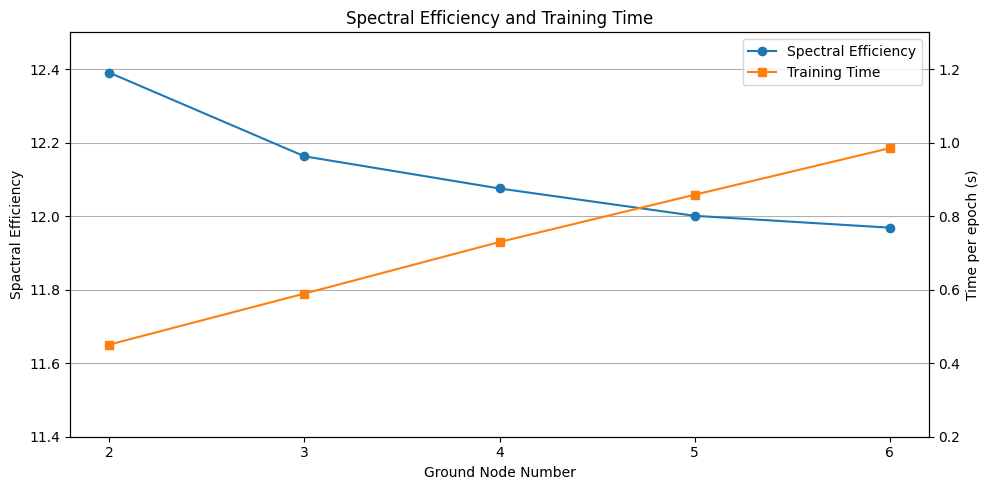

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# x 위치 설정 (지면 노드 번호)
x = np.arange(len(se_df.columns))

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()  # 오른쪽 y축

# grid를 bar 뒤에 그리도록 설정
ax1.set_axisbelow(True)
ax2.set_axisbelow(True)

# 왼쪽 y축: Spectral Efficiency (SE)
bars1 = ax1.plot(x, se_df.mean(), marker='o', color='tab:blue', label='Spectral Efficiency', zorder=3)
ax1.set_ylabel("Spactral Efficiency")
ax1.tick_params(axis='y')
ax1.set_ylim(11.4, 12.5)
ax1.set_xlabel("Ground Node Number")
ax1.set_xticks(x)
ax1.set_xticklabels(se_df.columns)
ax1.grid(True, axis='y', zorder=0)

# 오른쪽 y축: Training Time
bars2 = ax2.plot(x, time_avg, marker='s', color='tab:orange', label='Training Time', zorder=3)
ax2.set_ylabel("Time per epoch (s)")
ax2.tick_params(axis='y')
ax2.set_ylim(0.2, 1.3)
ax2.grid(False)

# 범례 추가: 두 축의 범례를 합쳐서 그림에 추가
fig.legend(loc='upper right', bbox_to_anchor=(1, 1), bbox_transform=ax1.transAxes)

plt.title("Spectral Efficiency and Training Time")
plt.tight_layout()
plt.savefig('./results/gn_num_test/result.pdf', dpi=300)
plt.savefig('./results/gn_num_test/result.svg', dpi=300)
plt.savefig('./results/gn_num_test/result.eps', dpi=300)
plt.savefig('./results/gn_num_test/result.png', dpi=300)

plt.show()


# test